# 📉 Notebook 2: ARIMA Forecasting
### StockSense AI — Classical Time Series Model

In [15]:
import sys
!{sys.executable} -m pip install plotly statsmodels

In [16]:
import yfinance as yf

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib, warnings
warnings.filterwarnings('ignore')
print('✅ Imports OK')

✅ Imports OK


## 1. Load Data

In [18]:
TICKER = 'AAPL'
df = pd.read_csv(f'../data/{TICKER}_processed.csv', index_col=0, parse_dates=True)
series = df['Close'].dropna()
print(f'Loaded {len(series)} data points')

Loaded 1562 data points


## 2. ACF / PACF Plots — Choose p, q

In [20]:
df = yf.download('AAPL', start='2020-01-01', end='2024-01-01', 
                  auto_adjust=True, progress=False)

In [21]:
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

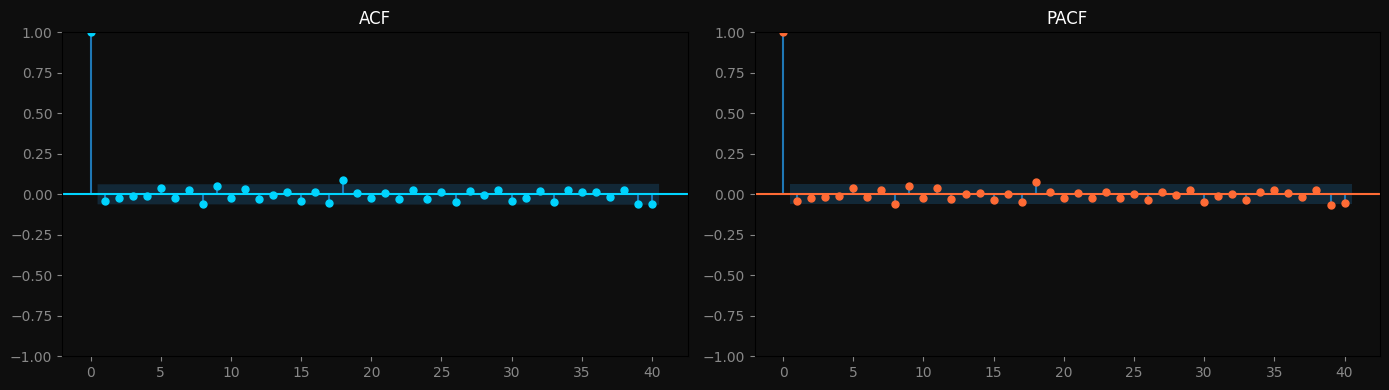

▶ Inspect ACF/PACF to pick p (PACF cutoff) and q (ACF cutoff). d=1 (one diff).


In [22]:
series = df['Close'].squeeze().astype(float)

diff_series = series.diff().dropna()
fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor='#0e0e0e')
for ax in axes: ax.set_facecolor('#0e0e0e')
plot_acf(diff_series, lags=40, ax=axes[0], color='#00d4ff')
plot_pacf(diff_series, lags=40, ax=axes[1], color='#ff6b35')
axes[0].set_title('ACF', color='white'); axes[1].set_title('PACF', color='white')
for ax in axes: ax.tick_params(colors='#888')
plt.tight_layout()
plt.show()
print('▶ Inspect ACF/PACF to pick p (PACF cutoff) and q (ACF cutoff). d=1 (one diff).')

In [28]:

df = yf.download('AAPL', start='2020-01-01', end='2024-01-01',
                  auto_adjust=True, progress=False)

In [29]:

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

In [30]:
series = df['Close'].astype(float)

## 3. Train / Test Split

In [31]:
SPLIT = int(len(series) * 0.85)
train = series[:SPLIT]
test  = series[SPLIT:]
print(f'Train: {len(train)}  |  Test: {len(test)}')

Train: 855  |  Test: 151


## 4. Fit ARIMA Model

In [32]:
# ARIMA(p,d,q) — adjust based on ACF/PACF
ORDER = (2, 1, 2)

model = ARIMA(train, order=ORDER)
fitted = model.fit()
print(fitted.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  855
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -2047.862
Date:                Thu, 12 Mar 2026   AIC                           4105.723
Time:                        22:43:56   BIC                           4129.473
Sample:                             0   HQIC                          4114.819
                                - 855                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9715      0.281      3.453      0.001       0.420       1.523
ar.L2         -0.7417      0.194     -3.829      0.000      -1.121      -0.362
ma.L1         -1.0123      0.286     -3.545      0.0

## 5. Rolling Forecast on Test Set

In [33]:
history = list(train)
predictions = []

for t in range(len(test)):
    m = ARIMA(history, order=ORDER)
    f = m.fit()
    yhat = f.forecast(steps=1)[0]
    predictions.append(yhat)
    history.append(test.iloc[t])
    if t % 20 == 0:
        print(f'  Step {t}/{len(test)}')

predictions = np.array(predictions)
print('✅ Rolling forecast complete')

  Step 0/151
  Step 20/151
  Step 40/151
  Step 60/151
  Step 80/151
  Step 100/151
  Step 120/151
  Step 140/151
✅ Rolling forecast complete


## 6. Metrics

In [34]:
rmse = np.sqrt(mean_squared_error(test, predictions))
mae  = mean_absolute_error(test, predictions)
mape = np.mean(np.abs((test.values - predictions) / test.values)) * 100

print(f'ARIMA {ORDER} Results')
print(f'  RMSE : {rmse:.4f}')
print(f'  MAE  : {mae:.4f}')
print(f'  MAPE : {mape:.2f}%')

ARIMA (2, 1, 2) Results
  RMSE : 2.0985
  MAE  : 1.6068
  MAPE : 0.89%


## 7. Forecast Plot

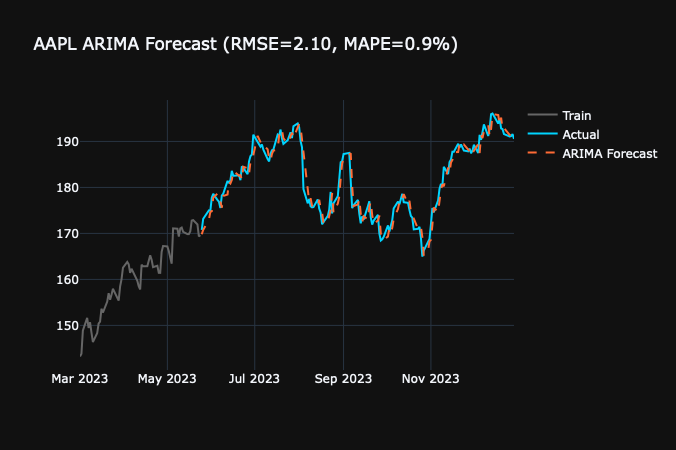

In [35]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=train.index[-60:], y=train[-60:], name='Train', line=dict(color='#666')))
fig.add_trace(go.Scatter(x=test.index, y=test, name='Actual', line=dict(color='#00d4ff')))
fig.add_trace(go.Scatter(x=test.index, y=predictions, name='ARIMA Forecast',
    line=dict(color='#ff6b35', dash='dash')))
fig.update_layout(title=f'{TICKER} ARIMA Forecast (RMSE={rmse:.2f}, MAPE={mape:.1f}%)',
    template='plotly_dark', height=450)
fig.show()

## 8. Future Forecast (30 days)

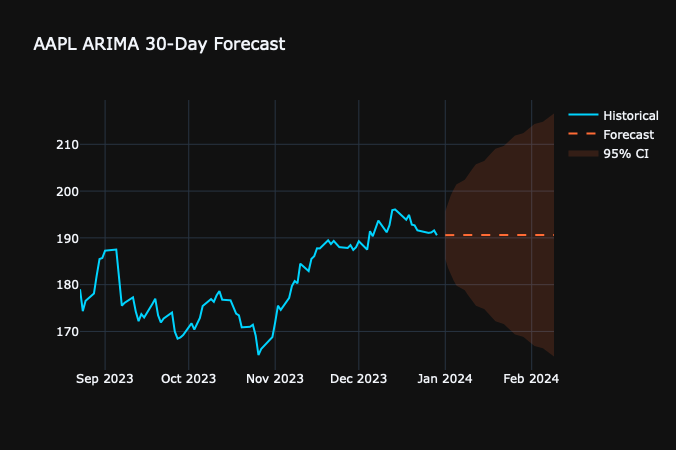

In [37]:
FORECAST_DAYS = 30
final_model = ARIMA(series, order=ORDER).fit()
forecast_res = final_model.get_forecast(steps=FORECAST_DAYS)
fc_mean = forecast_res.predicted_mean
fc_ci   = forecast_res.conf_int()

# Fix: assign future dates to forecast output
future_idx = pd.bdate_range(start=series.index[-1], periods=FORECAST_DAYS+1)[1:]
fc_mean.index = future_idx
fc_ci.index   = future_idx

fig = go.Figure()
fig.add_trace(go.Scatter(x=series.index[-90:], y=series.values[-90:],
    name='Historical', line=dict(color='#00d4ff')))
fig.add_trace(go.Scatter(x=future_idx, y=fc_mean.values,
    name='Forecast', line=dict(color='#ff6b35', dash='dash')))
fig.add_trace(go.Scatter(
    x=list(future_idx) + list(reversed(future_idx)),
    y=list(fc_ci.iloc[:,1]) + list(reversed(fc_ci.iloc[:,0])),
    fill='toself', fillcolor='rgba(255,107,53,0.15)',
    line=dict(color='rgba(0,0,0,0)'), name='95% CI'))
fig.update_layout(
    title=f'{TICKER} ARIMA 30-Day Forecast',
    template='plotly_dark', height=450)
fig.show()

## 9. Save Model

In [38]:
final_model.save(f'../models/saved_models/{TICKER}_arima.pkl')
print('✅ ARIMA model saved')

✅ ARIMA model saved
